In [7]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans 

In [2]:
image_path='../output_videos/cropped_img.jpg'
image=cv2.imread(image_path)
image_rgb=cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

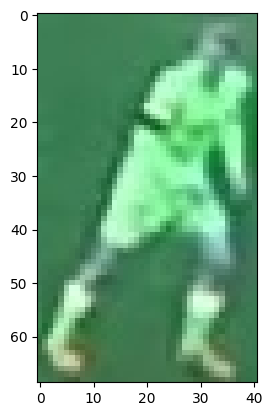

In [3]:
plt.imshow(image)
plt.show()

# Take the Top Half of the Image



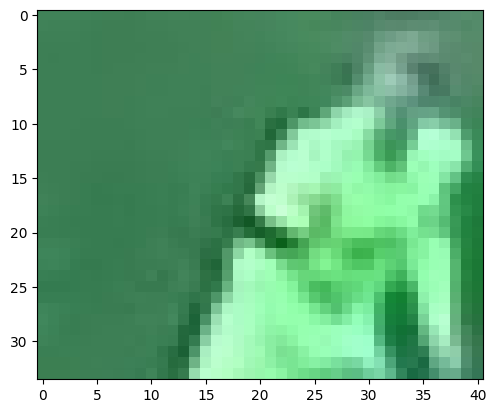

In [4]:
top_half_image= image[0: int(image.shape[0]/2), :]
plt.imshow(top_half_image)
plt.show()

# Cluster the Image into two Clusters

/Applications/anaconda3/envs/football-analysis/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Applications/anaconda3/envs/football-analysis/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Applications/anaconda3/envs/football-analysis/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Applications/anaconda3/envs/football-analysis/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Applications/anaconda3/envs/football-analysis/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Applications/anaconda3/envs/football-analysis/lib/python3.10/site-packages/

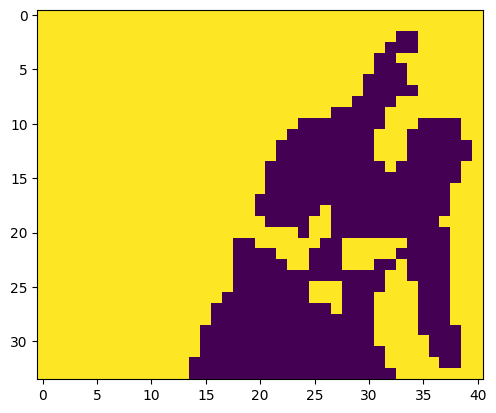

In [11]:
#Reshape the image into 2d array
image_2d=top_half_image.reshape(-1,3)

#perform k-means clustering with 2 clusters
kmeans= KMeans(n_clusters=2, random_state=0).fit(image_2d)

#Get the cluster labels
labels=kmeans.labels_

#reshape the labels into the original image shape
clustered_image=labels.reshape(top_half_image.shape[0], top_half_image.shape[1])

#Display the clustered image
plt.imshow(clustered_image)
plt.show()



In [12]:
corner_clusters=[clustered_image[0,0], clustered_image[0,-1], clustered_image[-1, 0], clustered_image[-1, -1]]
non_player_cluster=max(set(corner_clusters), key=corner_clusters.count)
print(non_player_cluster)


1


In [13]:
player_cluster=1-non_player_cluster
print(player_cluster)

0


In [14]:
kmeans.cluster_centers_[player_cluster]

array([142.92176039, 233.12713936, 168.3202934 ])